In [2]:
a=0
if not a:
    print("a is zero")

a is zero


In [1]:
from prm import *
from vrep import VrepWrapper

num_samples = 1000
step_length = 0.1
connect_prob = 0.05
radius = 0.1
local_planner = "line"
# start = np.array([float(i) for i in start.split()]) if start else None
# goal = np.array([float(i) for i in goal.split()]) if goal else None
dims = 3


environment = VrepWrapper()


# Set Model
model1 = PRM(
    num_samples=num_samples,
    num_dimensions=dims,
    lims=environment.lims,
    local_planner=local_planner,
    collision_func=environment.test_collisions,
    connect_prob=connect_prob,
    radius=radius,
    epsilon=step_length,
    name="robot1",
)

model2 = PRM(
    num_samples=num_samples,
    num_dimensions=dims,
    lims=environment.lims,
    local_planner=local_planner,
    collision_func=environment.test_collisions,
    connect_prob=connect_prob,
    radius=radius,
    epsilon=step_length,
    name="robot2",
)


environment.set_start_goal_config()

print("Builing PRM")
model1.build_prm()
model2.build_prm()


print("Finding Plan")
local_plan_1, plan_1, _ = model1.query(environment.robot1.start, environment.robot1.goal)
local_plan_2, plan_2, _ = model2.query(environment.robot2.start, environment.robot2.goal)


Builing PRM
Finding Plan


In [1]:
import pandas as pd
from vrep import VrepWrapper
from rrt import *
from prm import *
import numpy as np

_COLLISION = 0
_NEAR = 1
_NEIGH = 2
_TOTAL = 3



def time_test(num_samples):
    environment = VrepWrapper()

    method = 'rrt'
    step_length = 0.1
    connect_prob = 0.05
    connect = False
    bidirection = False
    star = True
    radius = 0.1
    # local_planner = local_planner
    # start = np.array([float(i) for i in start.split()]) if start else None
    # goal = np.array([float(i) for i in goal.split()]) if goal else None
    dims = 3


    environment = VrepWrapper()

    model1 = RRT(
        num_samples=num_samples,
        num_dimensions=dims,
        step_length=step_length,
        lims=environment.lims,
        connect_prob=connect_prob,
        collision_func=environment.test_collisions,
        radius=radius,
        name="robot1"
    )       
    model2 = RRT(
        num_samples=num_samples,
        num_dimensions=dims,
        step_length=step_length,
        lims=environment.lims,
        connect_prob=connect_prob,
        collision_func=environment.test_collisions,
        radius=radius,
        name="robot2"
    )

    environment.set_start_goal_config()

    if connect:
        plan_robot1 = model1.build_rrt_connect(environment.robot1.start, environment.robot1.goal)
        plan_robot2 = model2.build_rrt_connect(environment.robot2.start, environment.robot2.goal)
    elif bidirection:
        plan_robot1 = model1.build_bidirectional_rrt_connect(environment.robot1.start, environment.robot1.goal)
        plan_robot2 = model2.build_bidirectional_rrt_connect(environment.robot2.start, environment.robot2.goal)
    elif star:
        plan_robot1 = model1.build_rrt_star(environment.robot1.start, environment.robot1.goal)
        plan_robot2 = model2.build_rrt_star(environment.robot2.start, environment.robot2.goal)
    else:
        plan_robot1 = model1.build_rrt(environment.robot1.start, environment.robot1.goal)
        plan_robot2 = model2.build_rrt(environment.robot2.start, environment.robot2.goal)

    # model1.record
    # model2.record

    return model1.record, model2.record


def compute_path(path):
    # Compute the path from the start to the goal
    if path is None:
        return 0

    dist = 0
    for i in range(len(path) - 1):
        start = path[i]
        goal = path[i + 1]

        dist+=np.linalg.norm(start-goal)  
    return dist

df = pd.DataFrame(columns=['iter',
'r1_collision',
'r1_near',
'r1_neighbors',
'r1_total',
'r1_path'])

num_samples = 5000
# num_samples = list(range(100, 1000, 100))+list(range(1000, 5001, 1000))
rows = []  # Temporary list to store rows before concatenation

# for num_sample in num_samples:
r1,r2 = time_test(num_samples)

for iter, p1, t1 in r1:  
    # Create a dictionary for the current row
    t1=dict(t1)
    row = {
        'iter': iter,
        'r1_collision': t1[_COLLISION],
        'r1_near': t1[_NEAR],
        'r1_neighbors': t1[_NEIGH],
        'r1_total': t1[_TOTAL],
        'r1_path': compute_path(p1),
    }
    rows.append(row)  # Add the row to the list

# Concatenate all rows into the DataFrame
df = pd.concat([df, pd.DataFrame(rows)], ignore_index=True)

# Display the resulting DataFrame
df.to_csv('results_star_r1.csv', index=False)

print(df)

df = pd.DataFrame(columns=['iter',
'r2_collision',
'r2_near',
'r2_neighbors',
'r2_total',
'r2_path'])

num_samples = 50000
# num_samples = list(range(100, 1000, 100))+list(range(1000, 5001, 1000))
rows = []  # Temporary list to store rows before concatenation

# for num_sample in num_samples:
r1,r2 = time_test(num_samples, star=True)

for iter, p2, t2 in r2:  
    # Create a dictionary for the current row
    t2=dict(t2)
    row = {
        'iter': iter,
        'r2_collision': t2[_COLLISION],
        'r2_near': t2[_NEAR],
        'r2_neighbors': t2[_NEIGH],
        'r2_total': t2[_TOTAL],
        'r2_path': compute_path(p2),
    }
    rows.append(row)  # Add the row to the list

# Concatenate all rows into the DataFrame
df = pd.concat([df, pd.DataFrame(rows)], ignore_index=True)

# Display the resulting DataFrame
df.to_csv('results_star_r2.csv', index=False)

print(df)

# df = pd.DataFrame(columns=['r1_collision', 'r1_near', 'r1_neighbors', 'r1_total',  'r1_path',
#                            'r2_collision', 'r2_near', 'r2_neighbors', 'r2_total', 'r2_path',])

# num_samples = list(range(100, 1000, 100))+list(range(1000, 5001, 1000))
# rows = []  # Temporary list to store rows before concatenation

# for num_sample in num_samples:
#     t1, t2, p1, p2 = time_test(num_sample, connect=True)
    
#     # Assuming model1.time_table and model2.time_table are lists or arrays
    
#     # Create a dictionary for the current row
#     row = {
#         'r1_collision': t1[_COLLISION],
#         'r1_near': t1[_NEAR],
#         'r1_neighbors': t1[_NEIGH],
#         'r1_total': t1[_TOTAL],
#         'r1_path': compute_path(p1),
#         'r2_collision': t2[_COLLISION],
#         'r2_near': t2[_NEAR],
#         'r2_neighbors': t2[_NEIGH],
#         'r2_total': t2[_TOTAL],
#         'r2_path':  compute_path(p2),
#     }
#     rows.append(row)  # Add the row to the list
#     print(f"num_samples: {num_sample}")

# # Concatenate all rows into the DataFrame
# df = pd.concat([df, pd.DataFrame(rows)], ignore_index=True)

# # Display the resulting DataFrame
# df.to_csv('results_connect.csv', index=False)

# print(df)





# df = pd.DataFrame(columns=['r1_collision', 'r1_near', 'r1_neighbors', 'r1_total',  'r1_path',
#                            'r2_collision', 'r2_near', 'r2_neighbors', 'r2_total', 'r2_path',])

# num_samples = list(range(100, 1000, 100))+list(range(1000, 5001, 1000))
# rows = []  # Temporary list to store rows before concatenation

# for num_sample in num_samples:
#     t1, t2, p1, p2 = time_test(num_sample,connect=True)
    
#     # Assuming model1.time_table and model2.time_table are lists or arrays
    
#     # Create a dictionary for the current row
#     row = {
#         'r1_collision': t1[_COLLISION],
#         'r1_near': t1[_NEAR],
#         'r1_neighbors': t1[_NEIGH],
#         'r1_total': t1[_TOTAL],
#         'r1_path': compute_path(p1),
#         'r2_collision': t2[_COLLISION],
#         'r2_near': t2[_NEAR],
#         'r2_neighbors': t2[_NEIGH],
#         'r2_total': t2[_TOTAL],
#         'r2_path':  compute_path(p2),
#     }
#     rows.append(row)  # Add the row to the list
#     print(f"num_samples: {num_sample}")

# # Concatenate all rows into the DataFrame
# df = pd.concat([df, pd.DataFrame(rows)], ignore_index=True)

# # Display the resulting DataFrame
# df.to_csv('results_bidirectional.csv', index=False)

# print(df)







      iter  r1_collision    r1_near  r1_neighbors    r1_total   r1_path
0      297    420.414587  18.317621     18.068082  458.792791  4.159704
1      298    420.414587  18.317621     18.068082  458.792791  4.159704
2      299    420.414587  18.317621     18.068082  458.792791  4.159704
3      300    420.414587  18.317621     18.068082  458.792791  4.159704
4      301    420.414587  18.317621     18.068082  458.792791  4.159704
...    ...           ...        ...           ...         ...       ...
4698  4995    420.414587  18.317621     18.068082  458.792791  4.159704
4699  4996    420.414587  18.317621     18.068082  458.792791  4.159704
4700  4997    420.414587  18.317621     18.068082  458.792791  4.159704
4701  4998    420.414587  18.317621     18.068082  458.792791  4.159704
4702  4999    420.414587  18.317621     18.068082  458.792791  4.159704

[4703 rows x 6 columns]


/var/folders/0x/3xk_qp_x2xz488l5f9h_cmx00000gn/T/ipykernel_32618/499479373.py:115: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame(rows)], ignore_index=True)


TypeError: time_test() got an unexpected keyword argument 'star'

In [7]:
c=a.items()

In [11]:
dict(c)

{0: 1, 2: 2, 3: 3, 4: 4, 5: 5}

In [3]:
problem = 'env.txt'
method = 'rrt'
step_length = 1
connect_prob = 0.05
connect = False
bidirection = False 
star = True
radius = 2
num_samples = 1000
# local_planner = local_planner
# start = np.array([float(i) for i in start.split()]) if start else None
# goal = np.array([float(i) for i in goal.split()]) if goal else None
dims = 3

environment = PolygonEnvironment()
environment.read_env(problem)

model1 = RRT(
    num_samples=num_samples,
    num_dimensions=dims,
    step_length=step_length,
    lims=environment.lims,
    connect_prob=connect_prob,
    collision_func=environment.test_collisions,
    radius=radius,
    name="robot1"
)       
model2 = RRT(
    num_samples=num_samples,
    num_dimensions=dims,
    step_length=step_length,
    lims=environment.lims,
    connect_prob=connect_prob,
    collision_func=environment.test_collisions,
    radius=radius,
    name="robot2"
)

environment.set_start_goal_config()

if connect:
    plan_robot1 = model1.build_rrt_connect(environment.robot1.start, environment.robot1.goal)
    plan_robot2 = model2.build_rrt_connect(environment.robot2.start, environment.robot2.goal)
elif bidirection:
    plan_robot1 = model1.build_bidirectional_rrt_connect(environment.robot1.start, environment.robot1.goal)
    plan_robot2 = model2.build_bidirectional_rrt_connect(environment.robot2.start, environment.robot2.goal)
elif star:
    plan_robot1 = model1.build_rrt_star(environment.robot1.start, environment.robot1.goal)
    plan_robot2 = model2.build_rrt_star(environment.robot2.start, environment.robot2.goal)
else:
    plan_robot1 = model1.build_rrt(environment.robot1.start, environment.robot1.goal)
    plan_robot2 = model2.build_rrt(environment.robot2.start, environment.robot2.goal)

/Users/seongil-heo/miniconda3/envs/three9/lib/python3.9/site-packages/scipy/optimize/_differentiable_functions.py:504: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/Users/seongil-heo/miniconda3/envs/three9/lib/python3.9/site-packages/scipy/optimize/_differentiable_functions.py:231: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [2]:
import pandas as pd
from vrep import VrepWrapper
from rrt import *
from prm import *
import numpy as np
from collisions import PolygonEnvironment



In [ ]:
_COLLISION = 0
_NEAR = 1
_NEIGH = 2
_TOTAL = 3



def time_test(num_samples, connect=False, bidirection=False, star=False):

    problem = 'env.txt'
    method = 'rrt'
    step_length = 1
    connect_prob = 0.05
    connect = connect
    bidirection = bidirection
    star = star
    radius = 2
    # local_planner = local_planner
    # start = np.array([float(i) for i in start.split()]) if start else None
    # goal = np.array([float(i) for i in goal.split()]) if goal else None
    dims = 3

    environment = PolygonEnvironment()
    environment.read_env(problem)

    model1 = RRT(
        num_samples=num_samples,
        num_dimensions=dims,
        step_length=step_length,
        lims=environment.lims,
        connect_prob=connect_prob,
        collision_func=environment.test_collisions,
        radius=radius,
        name="robot1"
    )       
    model2 = RRT(
        num_samples=num_samples,
        num_dimensions=dims,
        step_length=step_length,
        lims=environment.lims,
        connect_prob=connect_prob,
        collision_func=environment.test_collisions,
        radius=radius,
        name="robot2"
    )

    environment.set_start_goal_config()

    if connect:
        plan_robot1 = model1.build_rrt_connect(environment.robot1.start, environment.robot1.goal)
        plan_robot2 = model2.build_rrt_connect(environment.robot2.start, environment.robot2.goal)
    elif bidirection:
        plan_robot1 = model1.build_bidirectional_rrt_connect(environment.robot1.start, environment.robot1.goal)
        plan_robot2 = model2.build_bidirectional_rrt_connect(environment.robot2.start, environment.robot2.goal)
    elif star:
        plan_robot1 = model1.build_rrt_star(environment.robot1.start, environment.robot1.goal)
        plan_robot2 = model2.build_rrt_star(environment.robot2.start, environment.robot2.goal)
    else:
        plan_robot1 = model1.build_rrt(environment.robot1.start, environment.robot1.goal)
        plan_robot2 = model2.build_rrt(environment.robot2.start, environment.robot2.goal)

    return model1.time_table, model2.time_table, plan_robot1, plan_robot2

def compute_path(path):
    # Compute the path from the start to the goal
    if path is None:
        return 0

    dist = 0
    for i in range(len(path) - 1):
        start = path[i]
        goal = path[i + 1]

        dist+=np.linalg.norm(start-goal)  
    return dist

df = pd.DataFrame(columns=['r1_collision', 'r1_near', 'r1_neighbors', 'r1_total',  'r1_path',
                           'r2_collision', 'r2_near', 'r2_neighbors', 'r2_total', 'r2_path',])

num_samples = list(range(100, 1000, 100))+list(range(1000, 5001, 1000))
rows = []  # Temporary list to store rows before concatenation

for num_sample in num_samples:
    t1, t2, p1, p2 = time_test(num_sample,star=True)
    
    # Assuming model1.time_table and model2.time_table are lists or arrays
    
    # Create a dictionary for the current row
    row = {
        'r1_collision': t1[_COLLISION],
        'r1_near': t1[_NEAR],
        'r1_neighbors': t1[_NEIGH],
        'r1_total': t1[_TOTAL],
        'r1_path': compute_path(p1),
        'r2_collision': t2[_COLLISION],
        'r2_near': t2[_NEAR],
        'r2_neighbors': t2[_NEIGH],
        'r2_total': t2[_TOTAL],
        'r2_path':  compute_path(p2),
    }
    rows.append(row)  # Add the row to the list
    print(f"num_samples: {num_sample}")

# Concatenate all rows into the DataFrame
df = pd.concat([df, pd.DataFrame(rows)], ignore_index=True)

# Display the resulting DataFrame
df.to_csv('results_star.csv', index=False)

print(df)


# df = pd.DataFrame(columns=['r1_collision', 'r1_near', 'r1_neighbors', 'r1_total',  'r1_path',
#                            'r2_collision', 'r2_near', 'r2_neighbors', 'r2_total', 'r2_path',])

# num_samples = list(range(100, 1000, 100))+list(range(1000, 5001, 1000))
# rows = []  # Temporary list to store rows before concatenation

# for num_sample in num_samples:
#     t1, t2, p1, p2 = time_test(num_sample, connect=True)
    
#     # Assuming model1.time_table and model2.time_table are lists or arrays
    
#     # Create a dictionary for the current row
#     row = {
#         'r1_collision': t1[_COLLISION],
#         'r1_near': t1[_NEAR],
#         'r1_neighbors': t1[_NEIGH],
#         'r1_total': t1[_TOTAL],
#         'r1_path': compute_path(p1),
#         'r2_collision': t2[_COLLISION],
#         'r2_near': t2[_NEAR],
#         'r2_neighbors': t2[_NEIGH],
#         'r2_total': t2[_TOTAL],
#         'r2_path':  compute_path(p2),
#     }
#     rows.append(row)  # Add the row to the list
#     print(f"num_samples: {num_sample}")

# # Concatenate all rows into the DataFrame
# df = pd.concat([df, pd.DataFrame(rows)], ignore_index=True)

# # Display the resulting DataFrame
# df.to_csv('results_connect.csv', index=False)

# print(df)





# df = pd.DataFrame(columns=['r1_collision', 'r1_near', 'r1_neighbors', 'r1_total',  'r1_path',
#                            'r2_collision', 'r2_near', 'r2_neighbors', 'r2_total', 'r2_path',])

# num_samples = list(range(100, 1000, 100))+list(range(1000, 5001, 1000))
# rows = []  # Temporary list to store rows before concatenation

# for num_sample in num_samples:
#     t1, t2, p1, p2 = time_test(num_sample,connect=True)
    
#     # Assuming model1.time_table and model2.time_table are lists or arrays
    
#     # Create a dictionary for the current row
#     row = {
#         'r1_collision': t1[_COLLISION],
#         'r1_near': t1[_NEAR],
#         'r1_neighbors': t1[_NEIGH],
#         'r1_total': t1[_TOTAL],
#         'r1_path': compute_path(p1),
#         'r2_collision': t2[_COLLISION],
#         'r2_near': t2[_NEAR],
#         'r2_neighbors': t2[_NEIGH],
#         'r2_total': t2[_TOTAL],
#         'r2_path':  compute_path(p2),
#     }
#     rows.append(row)  # Add the row to the list
#     print(f"num_samples: {num_sample}")

# # Concatenate all rows into the DataFrame
# df = pd.concat([df, pd.DataFrame(rows)], ignore_index=True)

# # Display the resulting DataFrame
# df.to_csv('results_bidirectional.csv', index=False)

# print(df)







In [ ]:
from collisions import PolygonEnvironment
import time
from vrep import VrepWrapper
from rrt import *
from prm import *

def time_test(num_samples):
    environment = VrepWrapper()

    method = 'rrt'
    step_length = 0.1
    connect_prob = 0.05
    connect = False
    bidirection = False
    star = False
    radius = 0.1
    # local_planner = local_planner
    # start = np.array([float(i) for i in start.split()]) if start else None
    # goal = np.array([float(i) for i in goal.split()]) if goal else None
    dims = 3


    environment = VrepWrapper()

    model1 = RRT(
        num_samples=num_samples,
        num_dimensions=dims,
        step_length=step_length,
        lims=environment.lims,
        connect_prob=connect_prob,
        collision_func=environment.test_collisions,
        radius=radius,
        name="robot1"
    )       
    model2 = RRT(
        num_samples=num_samples,
        num_dimensions=dims,
        step_length=step_length,
        lims=environment.lims,
        connect_prob=connect_prob,
        collision_func=environment.test_collisions,
        radius=radius,
        name="robot2"
    )

    environment.set_start_goal_config()

    if connect:
        plan_robot1 = model1.build_rrt_connect(environment.robot1.start, environment.robot1.goal)
        plan_robot2 = model2.build_rrt_connect(environment.robot2.start, environment.robot2.goal)
    elif bidirection:
        plan_robot1 = model1.build_bidirectional_rrt_connect(environment.robot1.start, environment.robot1.goal)
        plan_robot2 = model2.build_bidirectional_rrt_connect(environment.robot2.start, environment.robot2.goal)
    elif star:
        plan_robot1 = model1.build_rrt_star(environment.robot1.start, environment.robot1.goal)
        plan_robot2 = model2.build_rrt_star(environment.robot2.start, environment.robot2.goal)
    else:
        plan_robot1 = model1.build_rrt(environment.robot1.start, environment.robot1.goal)
        plan_robot2 = model2.build_rrt(environment.robot2.start, environment.robot2.goal)
    return model1.time_table, model2.time_table, plan_robot1, plan_robot2

In [ ]:
import pandas as pd

_COLLISION = 0
_NEAR = 1
_NEIGH = 2
_TOTAL = 3
df = pd.DataFrame()
num_samples = list(range(1000, 10001, 1000))
for num_sample in num_samples:
    t1,t2,p1,p2 = time_test(num_sample)
    
#  insert model1.time_table, model1.time_table into df
# df's columns are ['r1_collision', 'r1_near', 'r1_neighbors', 'r1_total', 'r2_collision', 'r2_near', 'r2_neighbors', 'r2_total']
#  robot1 model1.time_table
#  robot 2 model2.time_table
import pandas as pd

df = pd.DataFrame(columns=['r1_collision', 'r1_near', 'r1_neighbors', 'r1_total', 
                           'r2_collision', 'r2_near', 'r2_neighbors', 'r2_total'])
P={}
num_samples = list(range(1000, 10001, 1000))
for num_sample in num_samples:
    t1, t2, p1, p2 = time_test(num_sample)
    
    # Assuming model1.time_table and model2.time_table are lists or arrays
    df = df.append({
        'r1_collision': t1[_COLLISION],
        'r1_near': t1[_NEAR],
        'r1_neighbors': t1[_NEIGH],
        'r1_total': t1[_TOTAL],
        'r2_collision': t2[_COLLISION],
        'r2_near': t2[_NEAR],
        'r2_neighbors': t2[_NEIGH],
        'r2_total': t2[_TOTAL]
    }, ignore_index=True)

    P[num_sample] = (p1,p2)


df.to_csv('results.csv', index=False)

# Display the resulting DataFrame

df


AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:
t1

{0: 22.260725021362305, 1: 0.09409379959106445, 2: 0, 3: 22.374359846115112}

In [ ]:
t2

{0: 31.903438329696655, 1: 0.18254494667053223, 2: 0, 3: 32.114288330078125}

In [ ]:
p1

[[2.539857039,
  -0.809220588,
  0.533304724,
  0.73273653,
  0.177888697,
  0.01157112,
  0.157973681],
 array([ 2.46622877, -0.82010308,  0.56790667,  0.7228282 ,  0.14045927,
         0.04247341,  0.18641776]),
 array([ 2.39235316, -0.81814442,  0.59446557,  0.71402292,  0.17201567,
        -0.00751565,  0.20257132]),
 array([ 2.37294326, -0.76242221,  0.59689639,  0.69512762,  0.10531337,
        -0.02483634,  0.16507269]),
 array([ 2.30022307, -0.72166683,  0.56760597,  0.71900506,  0.14355395,
        -0.02025433,  0.15326696]),
 array([ 2.23525912, -0.69534505,  0.60384689,  0.70177915,  0.11641825,
         0.01304333,  0.11287348]),
 array([ 2.22713019, -0.64992712,  0.64371247,  0.69975755,  0.16031199,
         0.02785582,  0.0485951 ]),
 array([ 2.17451641, -0.57926288,  0.60884897,  0.72835382,  0.16746249,
         0.0166134 ,  0.04333929]),
 array([ 2.09847262, -0.56425988,  0.58828533,  0.68124663,  0.15235194,
         0.01648829,  0.0768349 ]),
 array([ 2.06534618, -0

In [ ]:
import numpy as np

def compute_path(path):
    # Compute the path from the start to the goal
    dist = 0
    for i in range(len(path) - 1):
        start = path[i]
        goal = path[i + 1]

        dist+=np.linalg.norm(start-goal)  
    return dist


Path_lengths = {}
for num_sample, (p1, p2) in P.items():
    Path_lengths[num_sample] = {}
    Path_lengths[num_sample]['r1_dist'] = compute_path(p1)
    Path_lengths[num_sample]['r2_dist'] = compute_path(p2)

# Add path lengths to the DataFrame
df['r1_path_length'] = df.index.map(lambda idx: Path_lengths[num_samples[idx]]['r1_dist'])
df['r2_path_length'] = df.index.map(lambda idx: Path_lengths[num_samples[idx]]['r2_dist'])

# Save the updated DataFrame to a CSV file
df.to_csv('results_with_path_lengths.csv', index=False)

# Display the updated DataFrame
print(df)

In [ ]:
import numpy as np

def compute_path(path):
    # Compute the path from the start to the goal
    dist = 0
    for i in range(len(path) - 1):
        start = path[i]
        goal = path[i + 1]

        dist+=np.linalg.norm(start-goal)  
    return dist

In [ ]:
t1,t2, compute_path(p1), compute_path(p2)

({0: 22.260725021362305, 1: 0.09409379959106445, 2: 0, 3: 22.374359846115112},
 {0: 31.903438329696655, 1: 0.18254494667053223, 2: 0, 3: 32.114288330078125},
 np.float64(5.0103495924820365),
 np.float64(5.018138708486846))

In [ ]:
row = {
    'r1_collision': float(t1[_COLLISION]),
    'r1_near': float(t1[_NEAR]),
    'r1_neighbors': float(t1[_NEIGH]),
    'r1_total': float(t1[_TOTAL]),
    'r1_path': float(compute_path(p1)),
    'r2_collision': float(t2[_COLLISION]),
    'r2_near': float(t2[_NEAR]),
    'r2_neighbors': float(t2[_NEIGH]),
    'r2_total': float(t2[_TOTAL]),
    'r2_path':float ( compute_path(p2)),
}

In [ ]:
row.values()

dict_values([22.260725021362305, 0.09409379959106445, 0.0, 22.374359846115112, 5.0103495924820365, 31.903438329696655, 0.18254494667053223, 0.0, 32.114288330078125, 5.018138708486846])

In [ ]:
df = pd.DataFrame(columns=['r1_collision', 'r1_near', 'r1_neighbors', 'r1_total',  'r1_path',
                           'r2_collision', 'r2_near', 'r2_neighbors', 'r2_total', 'r2_path',])
df = pd.concat([df, pd.DataFrame(row)], ignore_index=True)


ValueError: If using all scalar values, you must pass an index

In [ ]:
df=pd.read_csv('results.csv')

In [ ]:
df.index = list(range(100, 1000,100))+list(range(1000, 6000,1000))

In [ ]:
model1.time_table

{0: 15.644649982452393, 1: 0.049324989318847656, 2: 0, 3: 15.706984996795654}

In [ ]:
time_table[_COLLISION]  += 10.78

In [ ]:
time_table

{0: 20.78, 1: 0, 2: 0, 3: 0}

In [ ]:
_COLLISION = 0
_NEAR = 1
_NEIGH = 2
_TOTAL = 3


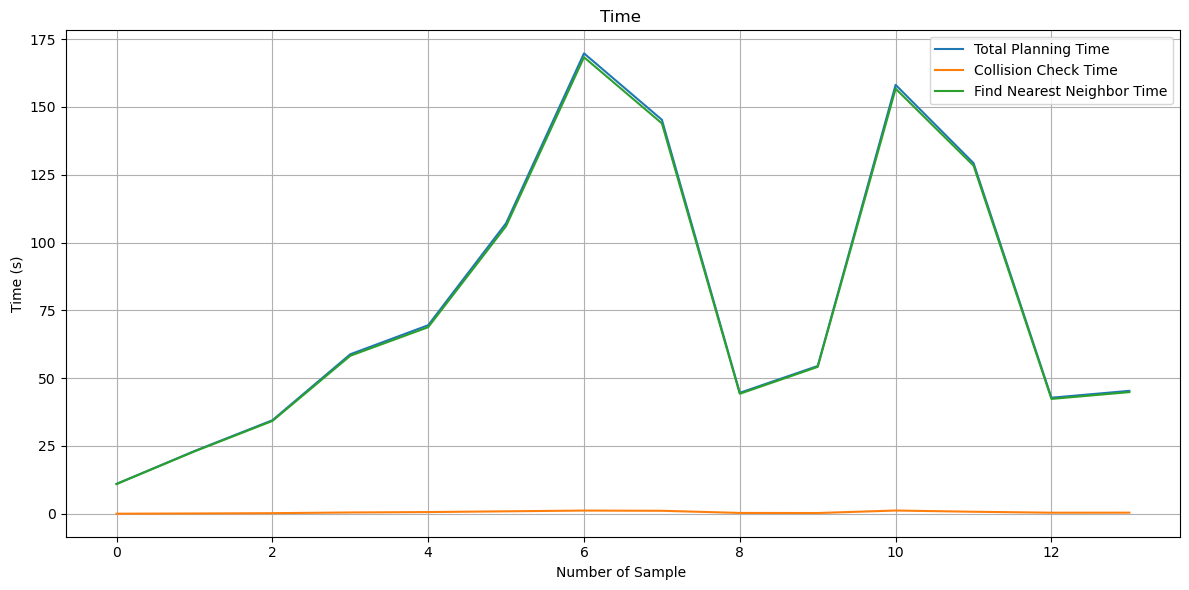

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 파일 로드
data = pd.read_csv('results_rrt.csv')

# 하나의 차트에 모든 지표 시각화
plt.figure(figsize=(12, 6))

# 각 지표 그리기
plt.plot(data['r1_total']+data['r2_total'], label='Total Planning Time')
plt.plot(data['r1_near']+data['r2_near']+data['r1_neighbors']+data['r2_neighbors'], label='Collision Check Time')
plt.plot(data['r1_collision']+data['r2_collision'], label='Find Nearest Neighbor Time')

# 그래프 설정
plt.title('Time ')
plt.xlabel('Number of Sample ')
plt.ylabel('Time (s)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# 그래프 출력
plt.show()

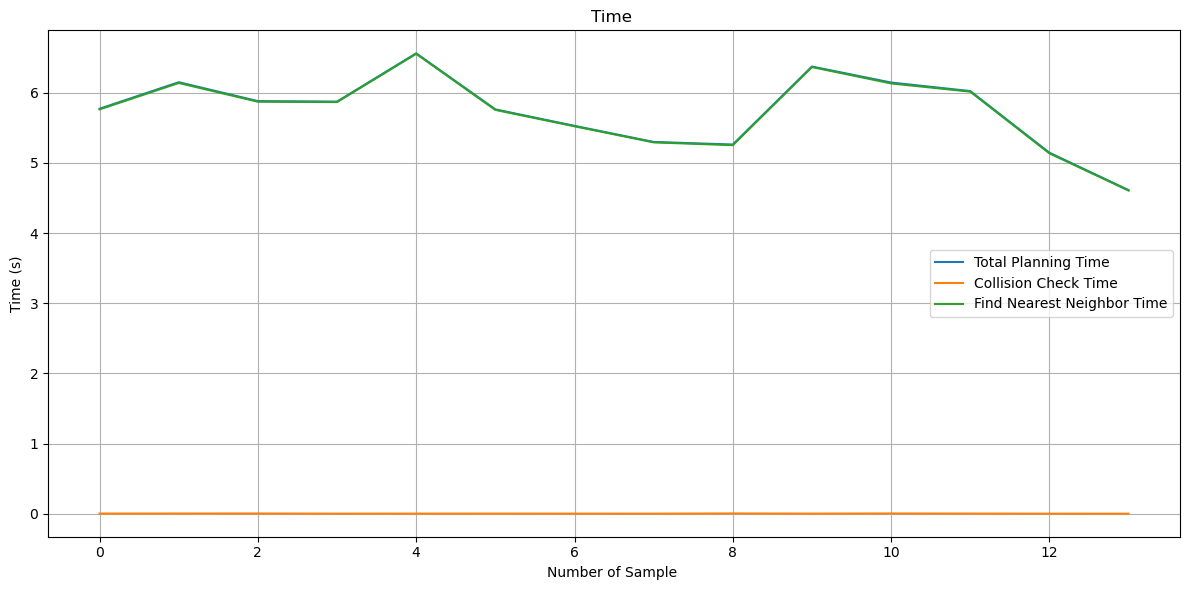

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 파일 로드
data_bi = pd.read_csv('results_bi.csv')

# 하나의 차트에 모든 지표 시각화
plt.figure(figsize=(12, 6))

# 각 지표 그리기
plt.plot(data['r1_total']+data['r2_total'], label='Total Planning Time')
plt.plot(data['r1_near']+data['r2_near']+data['r1_neighbors']+data['r2_neighbors'], label='Collision Check Time')
plt.plot(data['r1_collision']+data['r2_collision'], label='Find Nearest Neighbor Time')

# 그래프 설정
plt.title('Time ')
plt.xlabel('Number of Sample ')
plt.ylabel('Time (s)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# 그래프 출력
plt.show()

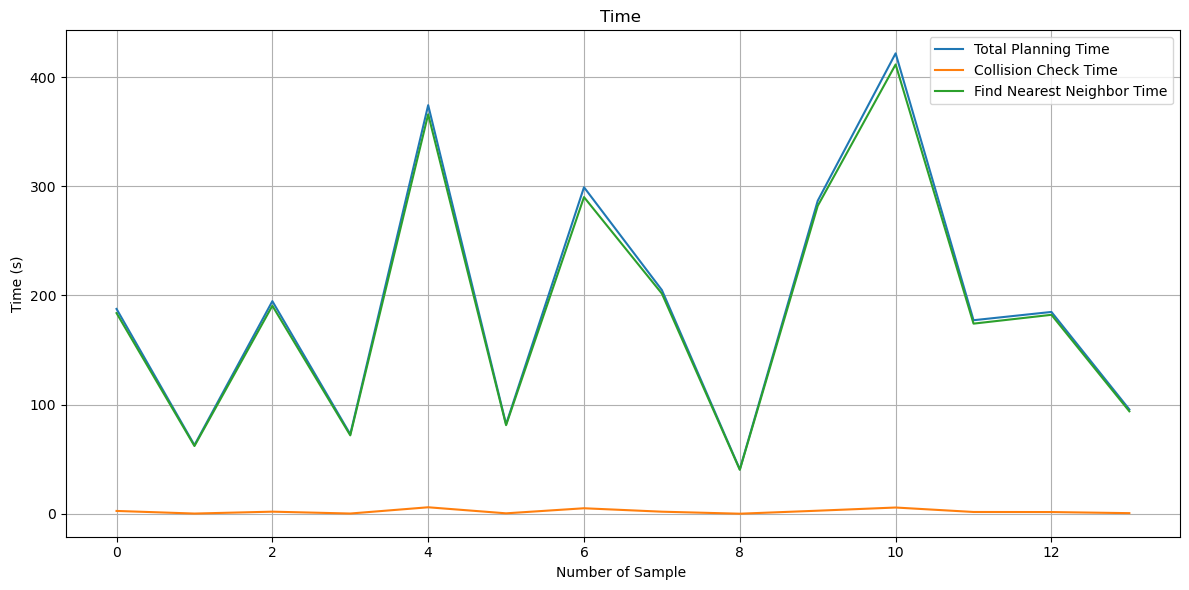

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 파일 로드
data_prm = pd.read_csv('results_prm.csv')

# 하나의 차트에 모든 지표 시각화
plt.figure(figsize=(12, 6))

# 각 지표 그리기
plt.plot(data['r1_total']+data['r2_total'], label='Total Planning Time')
plt.plot(data['r1_near']+data['r2_near']+data['r1_neighbors']+data['r2_neighbors'], label='Collision Check Time')
plt.plot(data['r1_collision']+data['r2_collision'], label='Find Nearest Neighbor Time')

# 그래프 설정
plt.title('Time ')
plt.xlabel('Number of Sample ')
plt.ylabel('Time (s)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# 그래프 출력
plt.show()

In [23]:
data['r1_total']

0     129.763153
1      50.550798
2     155.932599
3      26.825021
4     247.679382
5      68.410860
6     267.338430
7      28.001549
8      20.149917
9      62.898468
10     83.214524
11    136.747067
12    101.132679
13     76.029992
Name: r1_total, dtype: float64

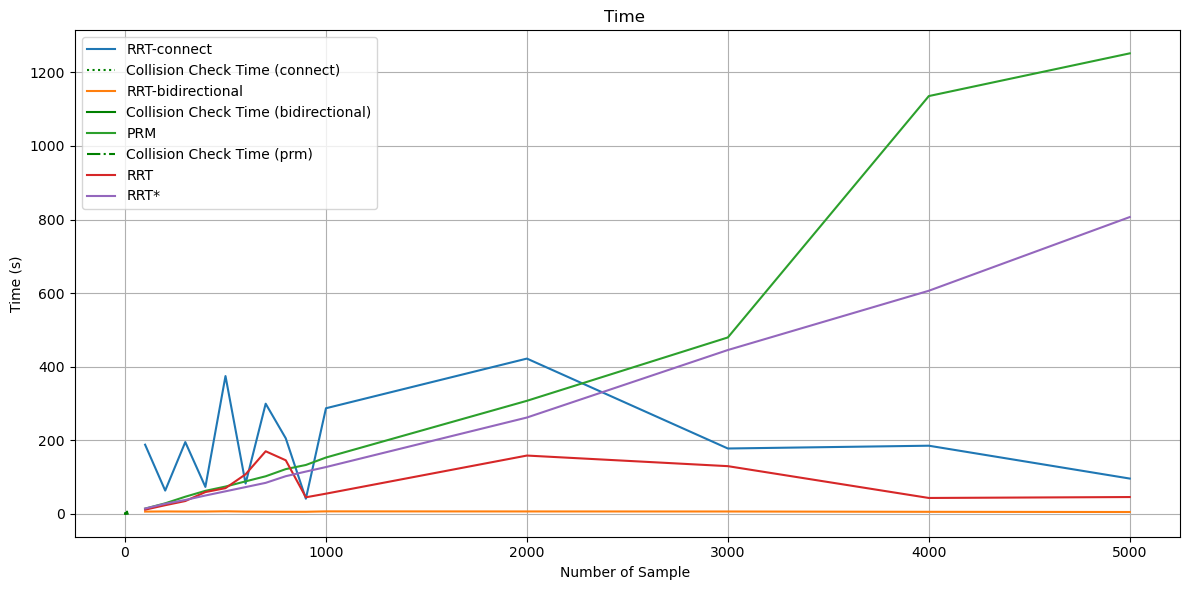

In [33]:
from turtle import color
import pandas as pd
import matplotlib.pyplot as plt
x = list(range(100,1000,100))+list(range(1000,5001,1000))  # [100, 200, ..., 1500]

# CSV 파일 로드
data = pd.read_csv('results_connect.csv')

# 하나의 차트에 모든 지표 시각화
plt.figure(figsize=(12, 6))

# 각 지표 그리기
plt.plot(x,data['r1_total']+data['r2_total'], label='RRT-connect')#, linestyle='dotted')#, color='red')  
plt.plot(data['r1_near']+data['r2_near']+data['r1_neighbors']+data['r2_neighbors'], label='Collision Check Time (connect)', linestyle='dotted', color='green')
# plt.plot(data['r1_collision']+data['r2_collision'], label='Find Nearest Neighbor Time (connect)', linestyle='dotted', color='blue')
# plt.plot(data['r1_path']+data['r2_path'], label='Path Planning Time', linestyle='dashed')

data_bi = pd.read_csv('results_bi.csv')
# 각 지표 그리기
plt.plot(x,data_bi['r1_total']+data_bi['r2_total'], label='RRT-bidirectional')# color='red')  
plt.plot(data_bi['r1_near']+data_bi['r2_near']+data_bi['r1_neighbors']+data_bi['r2_neighbors'], label='Collision Check Time (bidirectional)', color='green')
# plt.plot(data_bi['r1_collision']+data_bi['r2_collision'], label='Find Nearest Neighbor Time (bidirectional)', color='blue')



data_prm = pd.read_csv('results_prm.csv')
# 각 지표 그리기
plt.plot(x,data_prm['r1_build']+data_prm['r2_build'], label='PRM')#,linestyle='dashdot', color='red')
plt.plot(data_prm['r1_near']+data_prm['r2_near']+data_prm['r1_neighbors']+data_prm['r2_neighbors'], label='Collision Check Time (prm)', linestyle='dashdot', color='green')
# plt.plot(data_prm['r1_collision']+data_prm['r2_collision'], label='Find Nearest Neighbor Time (prm)', linestyle='dashdot', color='blue')

data = pd.read_csv('results_rrt.csv')
plt.plot(x,data['r1_total']+data['r2_total'], label='RRT')# color='red')  

data = pd.read_csv('results_star.csv')
plt.plot(x,data['r1_total']+data['r2_total'], label='RRT*')# color='red')  

# 그래프 설정
plt.title('Time ')
plt.xlabel('Number of Sample ')
plt.ylabel('Time (s)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# 그래프 출력
plt.show()

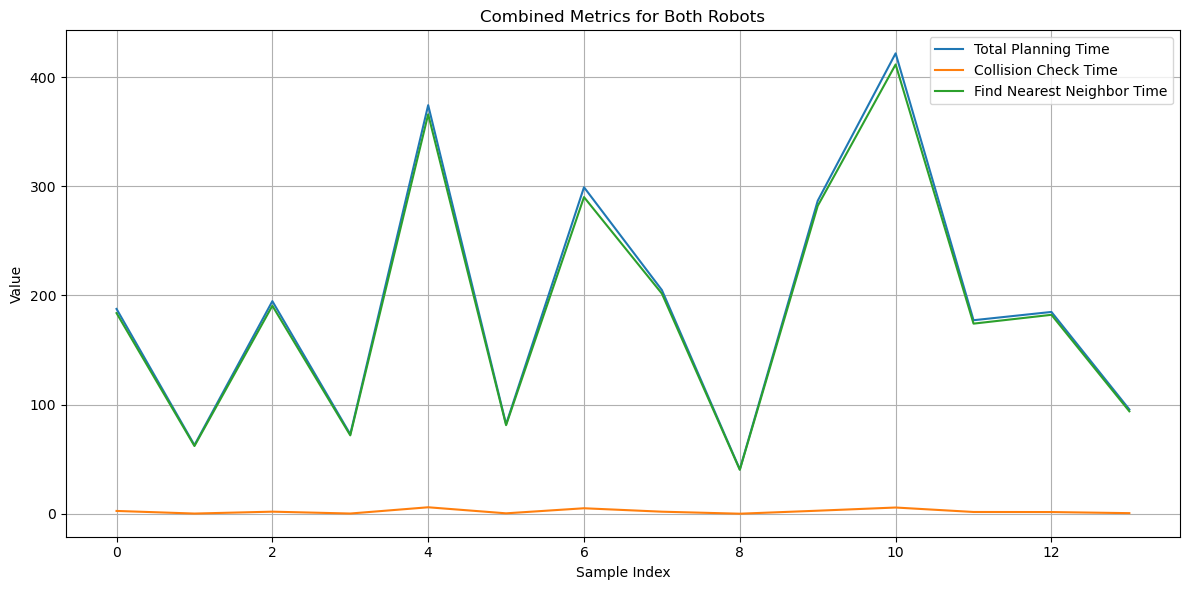

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 파일 로드
data = pd.read_csv('results_connect.csv')

# 하나의 차트에 모든 지표 시각화
plt.figure(figsize=(12, 6))

# 각 지표 그리기
plt.plot(data['r1_total']+data['r2_total'], label='Total Planning Time')
plt.plot(data['r1_near']+data['r2_near'], label='Collision Check Time')
plt.plot(data['r1_collision']+data['r2_collision'], label='Find Nearest Neighbor Time')

# 그래프 설정
plt.title('Combined Metrics for Both Robots')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

# 그래프 출력
plt.show()

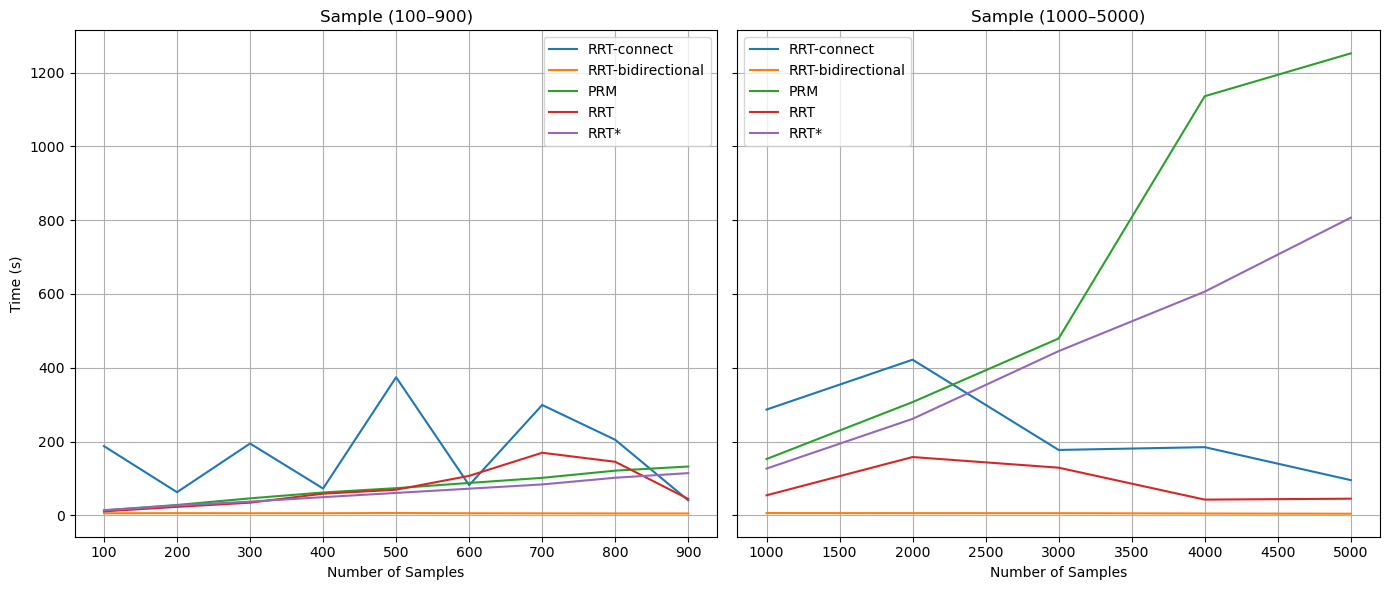

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# X축 분할
x1 = list(range(100, 1000, 100))     # 100 ~ 900
x2 = list(range(1000, 5001, 1000))   # 1000 ~ 5000

# 데이터 로드
data_connect = pd.read_csv('results_connect.csv')
data_bi = pd.read_csv('results_bi.csv')
data_prm = pd.read_csv('results_prm.csv')
data_rrt = pd.read_csv('results_rrt.csv')
data_star = pd.read_csv('results_star.csv')

# figure 설정
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 첫 번째 구간: 100 ~ 900
ax1.plot(x1, data_connect['r1_total'][:len(x1)] + data_connect['r2_total'][:len(x1)], label='RRT-connect')
ax1.plot(x1, data_bi['r1_total'][:len(x1)] + data_bi['r2_total'][:len(x1)], label='RRT-bidirectional')
ax1.plot(x1, data_prm['r1_build'][:len(x1)] + data_prm['r2_build'][:len(x1)], label='PRM')
ax1.plot(x1, data_rrt['r1_total'][:len(x1)] + data_rrt['r2_total'][:len(x1)], label='RRT')
ax1.plot(x1, data_star['r1_total'][:len(x1)] + data_star['r2_total'][:len(x1)], label='RRT*')
ax1.set_title('Sample (100–900)')
ax1.set_xlabel('Number of Samples')
ax1.set_ylabel('Time (s)')
ax1.grid(True)
ax1.legend()

# 두 번째 구간: 1000 ~ 5000
ax2.plot(x2, data_connect['r1_total'][len(x1):] + data_connect['r2_total'][len(x1):], label='RRT-connect')
ax2.plot(x2, data_bi['r1_total'][len(x1):] + data_bi['r2_total'][len(x1):], label='RRT-bidirectional')
ax2.plot(x2, data_prm['r1_build'][len(x1):] + data_prm['r2_build'][len(x1):], label='PRM')
ax2.plot(x2, data_rrt['r1_total'][len(x1):] + data_rrt['r2_total'][len(x1):], label='RRT')
ax2.plot(x2, data_star['r1_total'][len(x1):] + data_star['r2_total'][len(x1):], label='RRT*')
ax2.set_title('Sample (1000–5000)')
ax2.set_xlabel('Number of Samples')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

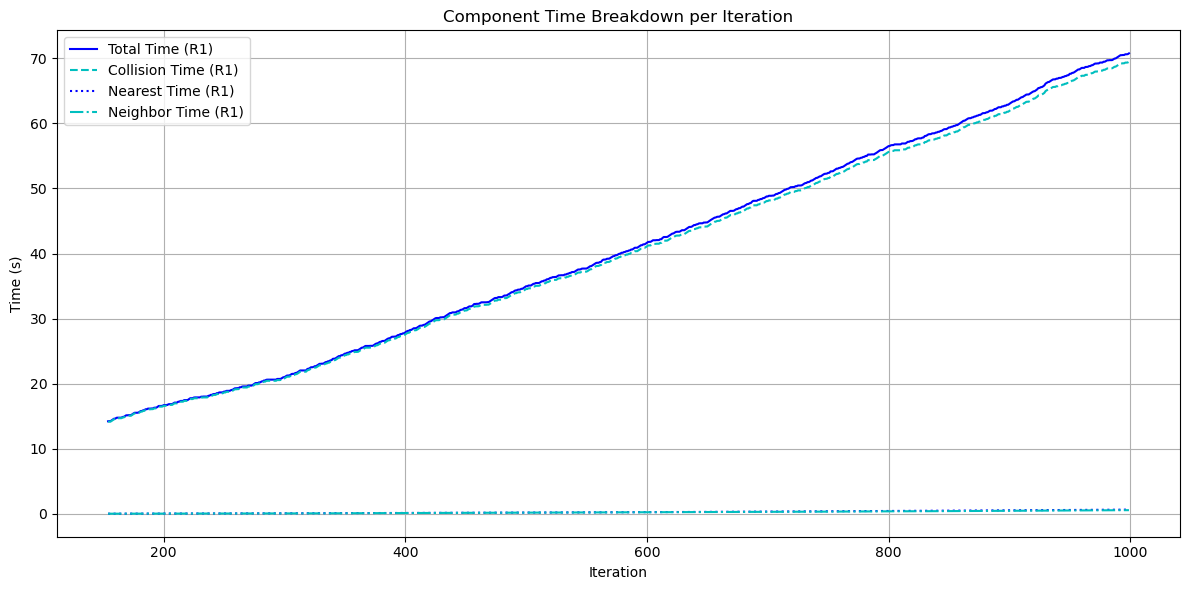

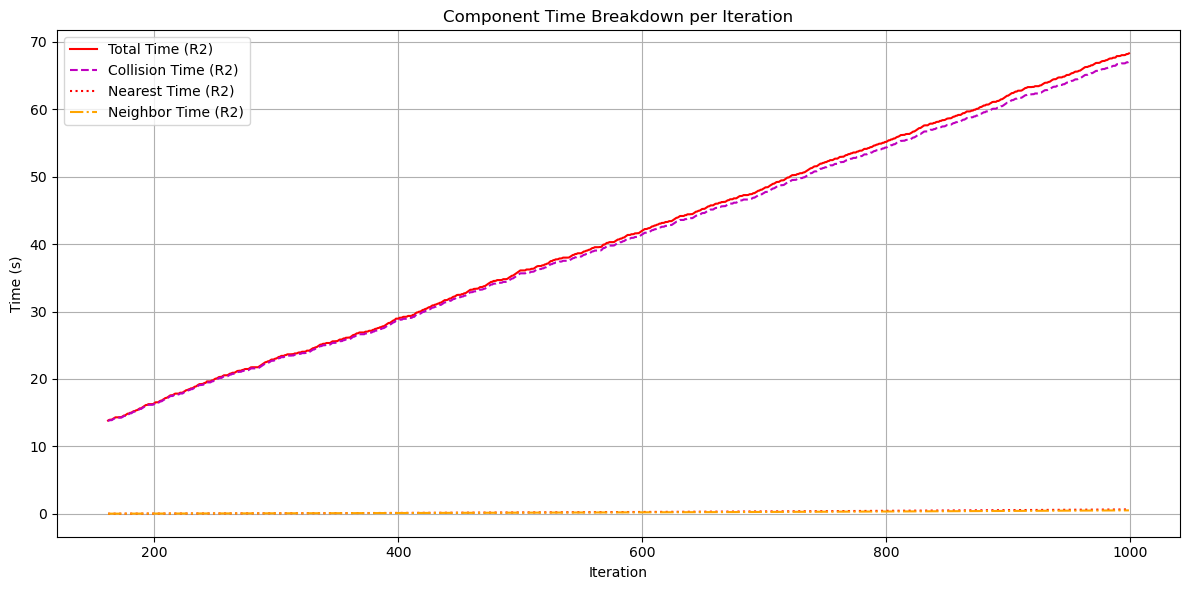

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

data1 = pd.read_csv("results_star_r1.csv")
data2 = pd.read_csv("results_star_r2.csv")

plt.figure(figsize=(12, 6))
plt.plot(data1['iter'], data1['r1_total'], label='Total Time (R1)', color='blue')
plt.plot(data1['iter'], data1['r1_collision'], label='Collision Time (R1)', color='c', linestyle='dashed')
plt.plot(data1['iter'], data1['r1_near'], label='Nearest Time (R1)', color='blue', linestyle='dotted')
plt.plot(data1['iter'], data1['r1_neighbors'], label='Neighbor Time (R1)', color='c', linestyle='dashdot')

plt.xlabel("Iteration")
plt.ylabel("Time (s)")
plt.title("Component Time Breakdown per Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(data2['iter'], data2['r2_total'], label='Total Time (R2)', color='red')
plt.plot(data2['iter'], data2['r2_collision'], label='Collision Time (R2)', color='m', linestyle='dashed')
plt.plot(data2['iter'], data2['r2_near'], label='Nearest Time (R2)', color='red', linestyle='dotted')
plt.plot(data2['iter'], data2['r2_neighbors'], label='Neighbor Time (R2)', color='orange', linestyle='dashdot')

plt.xlabel("Iteration")
plt.ylabel("Time (s)")
plt.title("Component Time Breakdown per Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

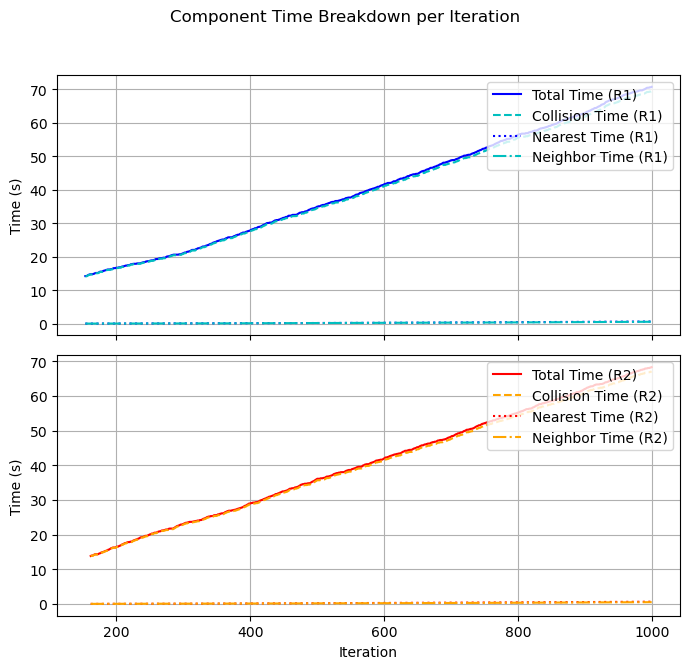

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
data1 = pd.read_csv("results_star_r1.csv")
data2 = pd.read_csv("results_star_r2.csv")

# 2행×1열 subplot 정의
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

# 전체 제목
fig.suptitle("Component Time Breakdown per Iteration")#, fontsize=16)

# ── 첫 번째 그래프 (R1)
ax1.plot(data1['iter'], data1['r1_total'],      label='Total Time (R1)',     color='blue')
ax1.plot(data1['iter'], data1['r1_collision'],  label='Collision Time (R1)', color='c', linestyle='dashed')
ax1.plot(data1['iter'], data1['r1_near'],       label='Nearest Time (R1)',   color='blue', linestyle='dotted')
ax1.plot(data1['iter'], data1['r1_neighbors'],  label='Neighbor Time (R1)',  color='c', linestyle='dashdot')
ax1.set_ylabel("Time (s)")
ax1.legend(loc='upper right')
ax1.grid(True)

# ── 두 번째 그래프 (R2)
ax2.plot(data2['iter'], data2['r2_total'],      label='Total Time (R2)',     color='red')
ax2.plot(data2['iter'], data2['r2_collision'],  label='Collision Time (R2)', color='orange', linestyle='dashed')
ax2.plot(data2['iter'], data2['r2_near'],       label='Nearest Time (R2)',   color='red', linestyle='dotted')
ax2.plot(data2['iter'], data2['r2_neighbors'],  label='Neighbor Time (R2)',  color='orange', linestyle='dashdot')
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Time (s)")
ax2.legend(loc='upper right')
ax2.grid(True)

# 레이아웃 조정 (suptitle이 겹치지 않도록)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

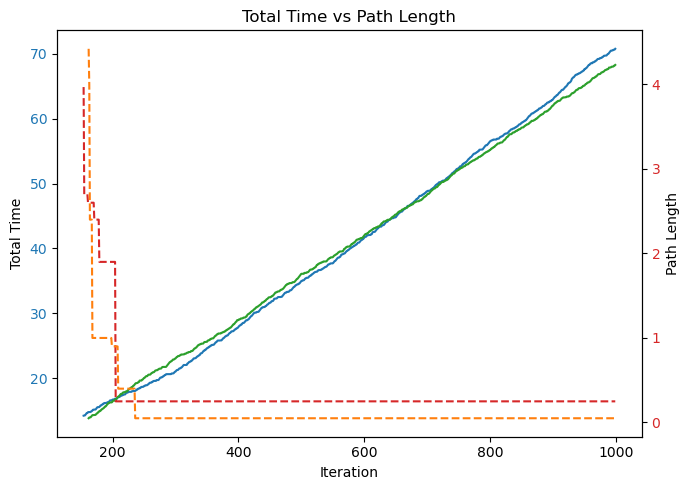

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

data1 = pd.read_csv("results_star_r1.csv")
data2 = pd.read_csv("results_star_r2.csv")

fig, ax1 = plt.subplots(figsize=(7, 5))

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Total Time')#, color='tab:blue')
ax1.plot(data1['iter'], data1['r1_total'], color='tab:blue', label='Total Time (R1)')
# ax1.plot(data1['iter'], data1['r1_collision'], color='tab:blue', label='Total Time (R1)')
ax1.plot(data2['iter'], data2['r2_total'], color='tab:green', label='Total Time (R2)')
# ax1.plot(data2['iter'], data2['r2_collision'], color='tab:green', label='Total Time (R2)')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Path Length')#, color='tab:red')
ax2.plot(data1['iter'], data1['r1_path'], color='tab:red', linestyle='--', label='Path Length (R1)')
ax2.plot(data2['iter'], data2['r2_path'], color='tab:orange', linestyle='--', label='Path Length (R2)')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()  # to ensure the right y-label is not slightly clipped
plt.title("Total Time vs Path Length")
fig.tight_layout()
plt.show()

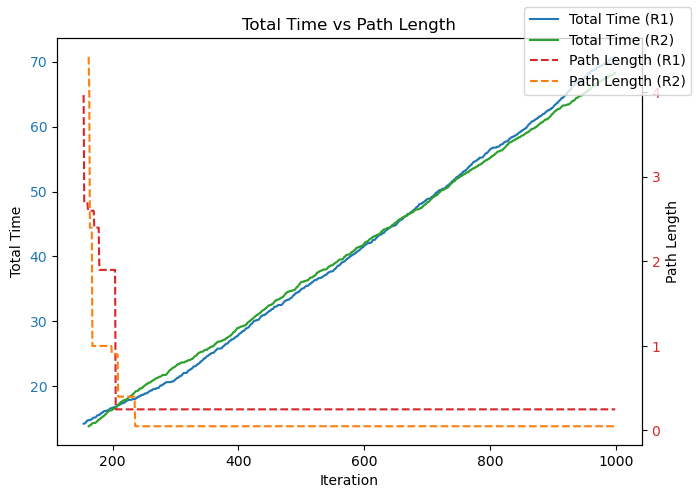

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

data1 = pd.read_csv("results_star_r1.csv")
data2 = pd.read_csv("results_star_r2.csv")

fig, ax1 = plt.subplots(figsize=(7, 5))

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Total Time')#, color='tab:blue')
ax1.plot(data1['iter'], data1['r1_total'], color='tab:blue', label='Total Time (R1)')
# ax1.plot(data1['iter'], data1['r1_collision'], color='tab:blue', label='Total Time (R1)')
ax1.plot(data2['iter'], data2['r2_total'], color='tab:green', label='Total Time (R2)')
# ax1.plot(data2['iter'], data2['r2_collision'], color='tab:green', label='Total Time (R2)')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Path Length')#, color='tab:red')
ax2.plot(data1['iter'], data1['r1_path'], color='tab:red', linestyle='--', label='Path Length (R1)')
ax2.plot(data2['iter'], data2['r2_path'], color='tab:orange', linestyle='--', label='Path Length (R2)')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.legend()#loc='upper left')
fig.tight_layout()  # to ensure the right y-label is not slightly clipped
plt.title("Total Time vs Path Length")
fig.tight_layout()
plt.show()

In [36]:
from coppeliasim_zmqremoteapi_client import RemoteAPIClient

client = RemoteAPIClient()
sim = client.require('sim')
ROBOT="LBRiiwa14R820"

robot1_joint_names = [f"/{ROBOT}[0]/joint{i}" for i in range(1, 1+7)]
robot2_joint_names = [f"/{ROBOT}[1]/joint{i}" for i in range(1, 1+7)]
robot1_joint_handles = [sim.getObject(jo) for jo in robot1_joint_names]
robot2_joint_handles = [sim.getObject(jo) for jo in robot2_joint_names]

THs1=[+0.686141298, +1.144134693, +1.798032392, +1.208946998, +0.072557405, -0.186249223, +0.046217752]
THs2=[+0.677549070, +1.111408814, +1.844167914, +1.213330375, +0.026713053, -0.169324889, +0.042448254]
for i in range(7):
    sim.setJointPosition(robot1_joint_handles[i], 1.5)#THs1[i])
    sim.setJointPosition(robot2_joint_handles[i], 1.5)#THs2[i])